# `reionemu` Package Example Usage

This notebook is a **full package tour** for `reionemu`.  
It is designed to demonstrate:

- the **public API**
- the **end-to-end pipeline**
- the **main configuration objects**
- the **return objects** from each major function
- the **model classes**
- the **training** and **k-fold cross-validation** utilities


## Pipeline covered in this notebook

The package naturally forms a pipeline:

1. **Condense raw simulation outputs** into a single HDF5 file  
2. **Compute angular power spectra** and write `/cl` products into the condensed file  
3. **Build ML-ready arrays** `X`, `Y`, and `ell`  
4. **Create DataLoaders** and optional normalization objects  
5. **Instantiate emulator models**  
6. **Train a model** with `fit()`  
7. **Evaluate with K-Fold cross-validation**

This notebook is structured in exactly that order.

## Package Imports & Organization

Import from the top-level package (after `pip install reionemu`). The library is organized into:

- **reionemu.simio** - Condense raw outputs, compute power spectra, build training arrays
- **reionemu.data** - Dataloaders and normalization
- **reionemu.models** - Baseline emulator (`FourParamEmulator`) and **reionemu.models.experimental** for POC variants
- **reionemu.training** - `fit()` and `kfold_cross_validate()` utilities
- **reionemu.tuning** - Ray Tune helpers for architecture search

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ray import tune

%config InlineBackend.figure_format = "retina"
plt.rc("figure", figsize=(6, 4), dpi=150)

import reionemu as remu

print(remu.__all__)

['condense_sim_root', 'CondenseConfig', 'CondenseStats', 'add_cl_to_condensed_h5', 'ClConfig', 'build_and_write_training', 'build_training_arrays', 'BuildXYConfig', 'BuildStats', 'make_dataloaders', 'load_training_arrays', 'DataLoaderConfig', 'Normalizer', 'FourParamEmulator', 'train_one_epoch', 'evaluate', 'evaluate_metrics', 'fit', 'FitConfig', 'mse', 'rmse', 'mean_relative_error', 'build_four_param_model', 'build_optimizer', 'kfold_cross_validate', 'KFoldConfig', 'train_four_param_tune', 'default_param_space', 'run_tune_four_param']


## Public API summary

The package root is set up to expose the main functions, configs, and model classes directly.
That means users can often stay at the top-level namespace instead of importing deeply from submodules.

The main groups are:

- **Simulation I/O**
  - `condense_sim_root`
  - `add_cl_to_condensed_h5`
  - `build_training_arrays`
  - `build_and_write_training`

- **Data utilities**
  - `load_training_arrays`
  - `make_dataloaders`
  - `Normalizer`

- **Models**
  - `FourParamEmulator`
  - Experimental variants in `reionemu.models.experimental`

- **Training**
  - `fit`
  - `kfold_cross_validate`
  - `default_param_space`
  - `run_tune_four_param`

## Set your file paths

Update these paths before running the pipeline cells below.

- `raw_sim_root` should point to the directory containing simulation folders like `sim1`, `sim2`, ...
- `condensed_h5` is the combined output file used throughout the rest of the notebook

In [2]:
repo_root = Path("/Users/robertxpearce/Desktop/reionization-emulator")

raw_sim_root = Path(
    r"/Users/robertxpearce/Desktop/reionization-emulator/data/raw/sims_v6"
)
condensed_h5 = Path(
    r"/Users/robertxpearce/Desktop/reionization-emulator/data/processed/TEST.h5"
)

print("raw_sim_root =", raw_sim_root)
print("condensed_h5 =", condensed_h5)

raw_sim_root = /Users/robertxpearce/Desktop/reionization-emulator/data/raw/sims_v6
condensed_h5 = /Users/robertxpearce/Desktop/reionization-emulator/data/processed/TEST.h5


# 1. Condense raw simulation outputs

The first stage scans a root directory of simulation folders and creates a single condensed HDF5 file.

### Main function
- `remu.condense_sim_root(...)`

### Main config
- `remu.CondenseConfig(overwrite=True, require_obs_and_pk=True)`

### Return object
- `CondenseStats`
  - `written`
  - `skipped_missing_obs_pk`
  - `skipped_read_error`
  - `skipped_validation_error`
  - property: `skipped_total`

In [3]:
%%time

condense_config = remu.CondenseConfig(
    overwrite=True,
    require_obs_and_pk=True,
)

condense_stats = remu.condense_sim_root(
    sim_root=raw_sim_root,
    out_path=condensed_h5,
    config=condense_config,
)

print(condense_stats)
print("Total Skipped:", condense_stats.skipped_total)

CondenseStats(written=1000, skipped_missing_obs_pk=0, skipped_read_error=0, skipped_validation_error=0)
Total Skipped: 0
CPU times: user 1.1 s, sys: 7.89 s, total: 8.98 s
Wall time: 12.9 s


# 2. Compute and attach angular power spectra

After condensation, the next stage computes the flat-sky angular power spectrum from each simulation's kSZ map
and writes a `/cl` group for every simulation.

### Main function
- `remu.add_cl_to_condensed_h5(...)`

### Main config
- `remu.ClConfig(nbins=5, ell_cut=1000.0, overwrite=True, sims_group="sims")`

### Return object
- `int` = number of simulations updated

In [4]:
%%time

cl_config = remu.ClConfig(
    nbins=5,
    ell_cut=1000.0,
    overwrite=True,
    sims_group="sims",
)

n_updated = remu.add_cl_to_condensed_h5(
    h5_path=condensed_h5,
    config=cl_config,
)

print("Simulations Updated:", n_updated)

Simulations Updated: 1000
CPU times: user 2min 54s, sys: 1.5 s, total: 2min 56s
Wall time: 2min 58s


# 3. Build machine-learning arrays

This stage constructs the training arrays from the condensed HDF5 file.

### Main functions
- `remu.build_training_arrays(...)`
- `remu.build_and_write_training(...)`

### Main config
- `remu.BuildXYConfig(...)`

### Return objects from `build_training_arrays`
A 6-tuple:

1. `X` - parameter matrix
2. `Y` - target matrix
3. `ell` - ell bin centers
4. `sim_ids` - simulation IDs
5. `param_names` - parameter names used in `X`
6. `BuildStats` - processed/skip statistics

In [5]:
%%time

build_config = remu.BuildXYConfig(
    sims_group="sims",
    params_group="params",
    cl_group="cl",
    param_names=("zmean_zre", "alpha_zre", "kb_zre", "b0_zre"),
    y_source="dl_ksz",
    y_transform="ln",
    eps=1e-30,
)

n_written = remu.build_and_write_training(
    condensed_h5,
    config=build_config,
    overwrite=True,
)

print("Training Samples Written:", n_written)

Training Samples Written: 1000
CPU times: user 221 ms, sys: 27.1 ms, total: 248 ms
Wall time: 355 ms


# 4. Load the training arrays

Once `/training` exists in the condensed HDF5 file, the package can load the arrays directly.

### Main function
- `remu.load_training_arrays(h5_path)`

### Return object
A 3-tuple:

1. `X`
2. `Y`
3. `ell`

In [6]:
%%time

X_loaded, Y_loaded, ell_loaded = remu.load_training_arrays(condensed_h5)

print("X_loaded.shape =", X_loaded.shape)
print("Y_loaded.shape =", Y_loaded.shape)
print("ell_loaded.shape =", ell_loaded.shape)
print("X dtype:", X_loaded.dtype)
print("Y dtype:", Y_loaded.dtype)
print("ell dtype:", ell_loaded.dtype)

X_loaded.shape = (1000, 4)
Y_loaded.shape = (1000, 5)
ell_loaded.shape = (5,)
X dtype: float32
Y dtype: float32
ell dtype: float32
CPU times: user 888 μs, sys: 755 μs, total: 1.64 ms
Wall time: 1.13 ms


# 5. Build DataLoaders

The data-loading utility creates PyTorch DataLoaders from the HDF5 training arrays and can optionally fit/apply normalization using **training split only** statistics.

### Main function
- `remu.make_dataloaders(...)`

### Main config
- `remu.DataLoaderConfig(...)`

### Return object
A 3-tuple:

1. `loaders` - dict of `torch.utils.data.DataLoader` objects keyed by split name
2. `norms` - dict with keys `"X"` and `"Y"`; values are `Normalizer` objects or `None`
3. `ell` - ell bin centers

In [7]:
%%time

dl_config = remu.DataLoaderConfig(
    batch_size=32,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False,
)

loaders, norms, ell_dl = remu.make_dataloaders(
    condensed_h5,
    split={"train": 0.8, "val": 0.2},
    config=dl_config,
)

print("Loader Keys:", list(loaders.keys()))
print("Norm Keys:", list(norms.keys()))
print("ell Dl Shape:", ell_dl.shape)
print("X Normalizer Type:", type(norms["X"]))
print("Y Normalizer Type:", type(norms["Y"]))
if norms["X"] is not None:
    print("X Mean:", norms["X"].mean)
    print("X STD :", norms["X"].std)

if norms["Y"] is not None:
    print("Y Mean:", norms["Y"].mean)
    print("Y STD :", norms["Y"].std)

Loader Keys: ['train', 'val']
Norm Keys: ['X', 'Y']
ell Dl Shape: (5,)
X Normalizer Type: <class 'reionemu.data.normalization.Normalizer'>
Y Normalizer Type: <class 'NoneType'>
X Mean: [7.9963284  0.4994851  1.0572479  0.45696917]
X STD : [0.571093   0.23162802 0.54692036 0.20266293]
CPU times: user 1.42 ms, sys: 1.74 ms, total: 3.16 ms
Wall time: 6.09 ms


# 7. Model classes

The package currently exposes one stable PyTorch model class plus experimental variants:

- `remu.FourParamEmulator`
- `reionemu.models.experimental.POCEmulatorThreeParams`

All of these are straightforward `torch.nn.Module` subclasses.
This section shows:

- how to instantiate them
- what their architectures look like
- the expected input/output shapes
- how many trainable parameters they contain

In [8]:
%%time

four_model = remu.FourParamEmulator()
from reionemu.models.experimental import POCEmulatorThreeParams

three_model = POCEmulatorThreeParams()

print("FourParamEmulator")
print(four_model)
params = sum(
    params.numel() for params in four_model.parameters() if params.requires_grad
)
print("Trainable Params:", params)
print()

print("POCEmulatorThreeParams")
print(three_model)
params = sum(
    params.numel() for params in three_model.parameters() if params.requires_grad
)
print("Trainable Params:", params)

FourParamEmulator
FourParamEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=5, bias=True)
  )
)
Trainable Params: 625

POCEmulatorThreeParams
POCEmulatorThreeParams(
  (fc1): Linear(in_features=3, out_features=5, bias=True)
  (out): Linear(in_features=5, out_features=5, bias=True)
  (activation): GELU(approximate='none')
)
Trainable Params: 50
CPU times: user 936 μs, sys: 2.33 ms, total: 3.27 ms
Wall time: 8.72 ms


# 8. Ray Tune

The package now exposes Ray Tune helpers for hyperparameter search over the four-parameter emulator.

A useful workflow is:

- define a compact search space
- run `remu.run_tune_four_param(...)` on a train/validation split
- inspect the best trial
- reuse that winning configuration with `fit()` and `kfold_cross_validate()`

Below, we tune a small search space and store the best config for the remaining sections.


In [9]:
%%time

X = X_loaded
Y = Y_loaded

split_idx = int(0.8 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train, Y_val = Y[:split_idx], Y[split_idx:]

print("Train Shapes:", X_train.shape, Y_train.shape)
print("Val Shapes:  ", X_val.shape, Y_val.shape)
print()

tune_space = {
    # Architecture
    "hidden_dim": tune.choice([20, 24, 28, 32, 40]),
    "num_hidden_layers": tune.choice([2, 3]),
    "activation": tune.choice(["relu", "silu", "tanh"]),

    # Optimization
    "optimizer": tune.choice(["adamw", "adam"]),
    "lr": tune.loguniform(4e-4, 2.5e-3),
    "weight_decay": tune.loguniform(1e-8, 3e-5),

    # Training
    "batch_size": tune.choice([16, 32, 64]),
    "epochs": 250,
    "early_stopping_patience": tune.choice([10, 15, 20]),
    "gradient_clipping": tune.choice([None, 0.5, 1.0]),

    # Preprocessing
    "normalize_X": True,
    "normalize_Y": False,
}

results = remu.run_tune_four_param(
    X_train=X_train,
    Y_train=Y_train,
    X_val=X_val,
    Y_val=Y_val,
    param_space=tune_space,
    num_samples=400,
    max_concurrent_trials=1,
    device="mps",
    storage_path=str(repo_root / "ray_results"),
    experiment_name="four_param_search"
)

best = results.get_best_result(metric="val_loss", mode="min")
best_config = dict(best.config)

print("Best config:")
print(best_config)
print()
print("Best metrics:")
print({
    "best_epoch": best.metrics.get("best_epoch"),
    "best_val_loss": best.metrics.get("best_val_loss"),
    "val_rmse": best.metrics.get("val_rmse"),
    "val_relative_error": best.metrics.get("val_relative_error"),
})

(train_four_param_tune pid=71411) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/robertxpearce/Desktop/reionization-emulator/ray_results/four_param_search/train_four_param_tune_31016_00000_0_activation=relu,batch_size=64,early_stopping_patience=15,gradient_clipping=0.5000,hidden_dim=4_2026-04-03_22-36-12/checkpoint_000000)
(train_four_param_tune pid=71411) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/robertxpearce/Desktop/reionization-emulator/ray_results/four_param_search/train_four_param_tune_31016_00000_0_activation=relu,batch_size=64,early_stopping_patience=15,gradient_clipping=0.5000,hidden_dim=4_2026-04-03_22-36-12/checkpoint_000001)
(train_four_param_tune pid=71411) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/robertxpearce/Desktop/reionization-emulator/ray_results/four_param_search/train_four_param_tune_31016_00000_0_activation=relu,batch_size=64,early_stopping_patience=15,gradient_cli

Best config:
{'hidden_dim': 28, 'num_hidden_layers': 3, 'activation': 'silu', 'optimizer': 'adam', 'lr': 0.001202961684835979, 'weight_decay': 1.4623871314145397e-05, 'batch_size': 32, 'epochs': 250, 'early_stopping_patience': 20, 'gradient_clipping': 0.5, 'normalize_X': True, 'normalize_Y': False, 'device': 'mps'}

Best metrics:
{'best_epoch': 85, 'best_val_loss': 0.0037253909558057786, 'val_rmse': 0.060419513136148455, 'val_relative_error': 0.42992456912994387}
CPU times: user 6.17 s, sys: 5.25 s, total: 11.4 s
Wall time: 6min 40s


# 9. Train a model with `fit()`

Now that Ray Tune has selected a configuration, we can build that architecture directly and train it with the standard `fit()` utility.

The training utility expects:

- a model
- `train_loader`
- `val_loader`
- an optimizer
- a loss function
- a `FitConfig`

### Main function
- `remu.fit(...)`

### Main config
- `remu.FitConfig(...)`

### Return object
A `dict` with:
- `"train_loss"` $\rightarrow$ list of train losses by epoch
- `"val_loss"` $\rightarrow$ list of validation losses by epoch


Epoch 001: train=0.344632, val=0.334161
Epoch 002: train=0.245898, val=0.212916
Epoch 003: train=0.115595, val=0.055093
Epoch 004: train=0.036903, val=0.022649
Epoch 005: train=0.017555, val=0.013405
Epoch 006: train=0.011717, val=0.009955
Epoch 007: train=0.009397, val=0.008813
Epoch 008: train=0.008310, val=0.007847
Epoch 009: train=0.007594, val=0.007506
Epoch 010: train=0.007146, val=0.007050
Epoch 011: train=0.006759, val=0.006456
Epoch 012: train=0.006450, val=0.006744
Epoch 013: train=0.006360, val=0.006641
Epoch 014: train=0.006050, val=0.006105
Epoch 015: train=0.005767, val=0.005827
Epoch 016: train=0.005759, val=0.005608
Epoch 017: train=0.005538, val=0.005819
Epoch 018: train=0.005431, val=0.005626
Epoch 019: train=0.005190, val=0.005507
Epoch 020: train=0.005202, val=0.005129
Epoch 021: train=0.005001, val=0.004976
Epoch 022: train=0.005003, val=0.005215
Epoch 023: train=0.004992, val=0.005742
Epoch 024: train=0.004860, val=0.004946
Epoch 025: train=0.004886, val=0.004823


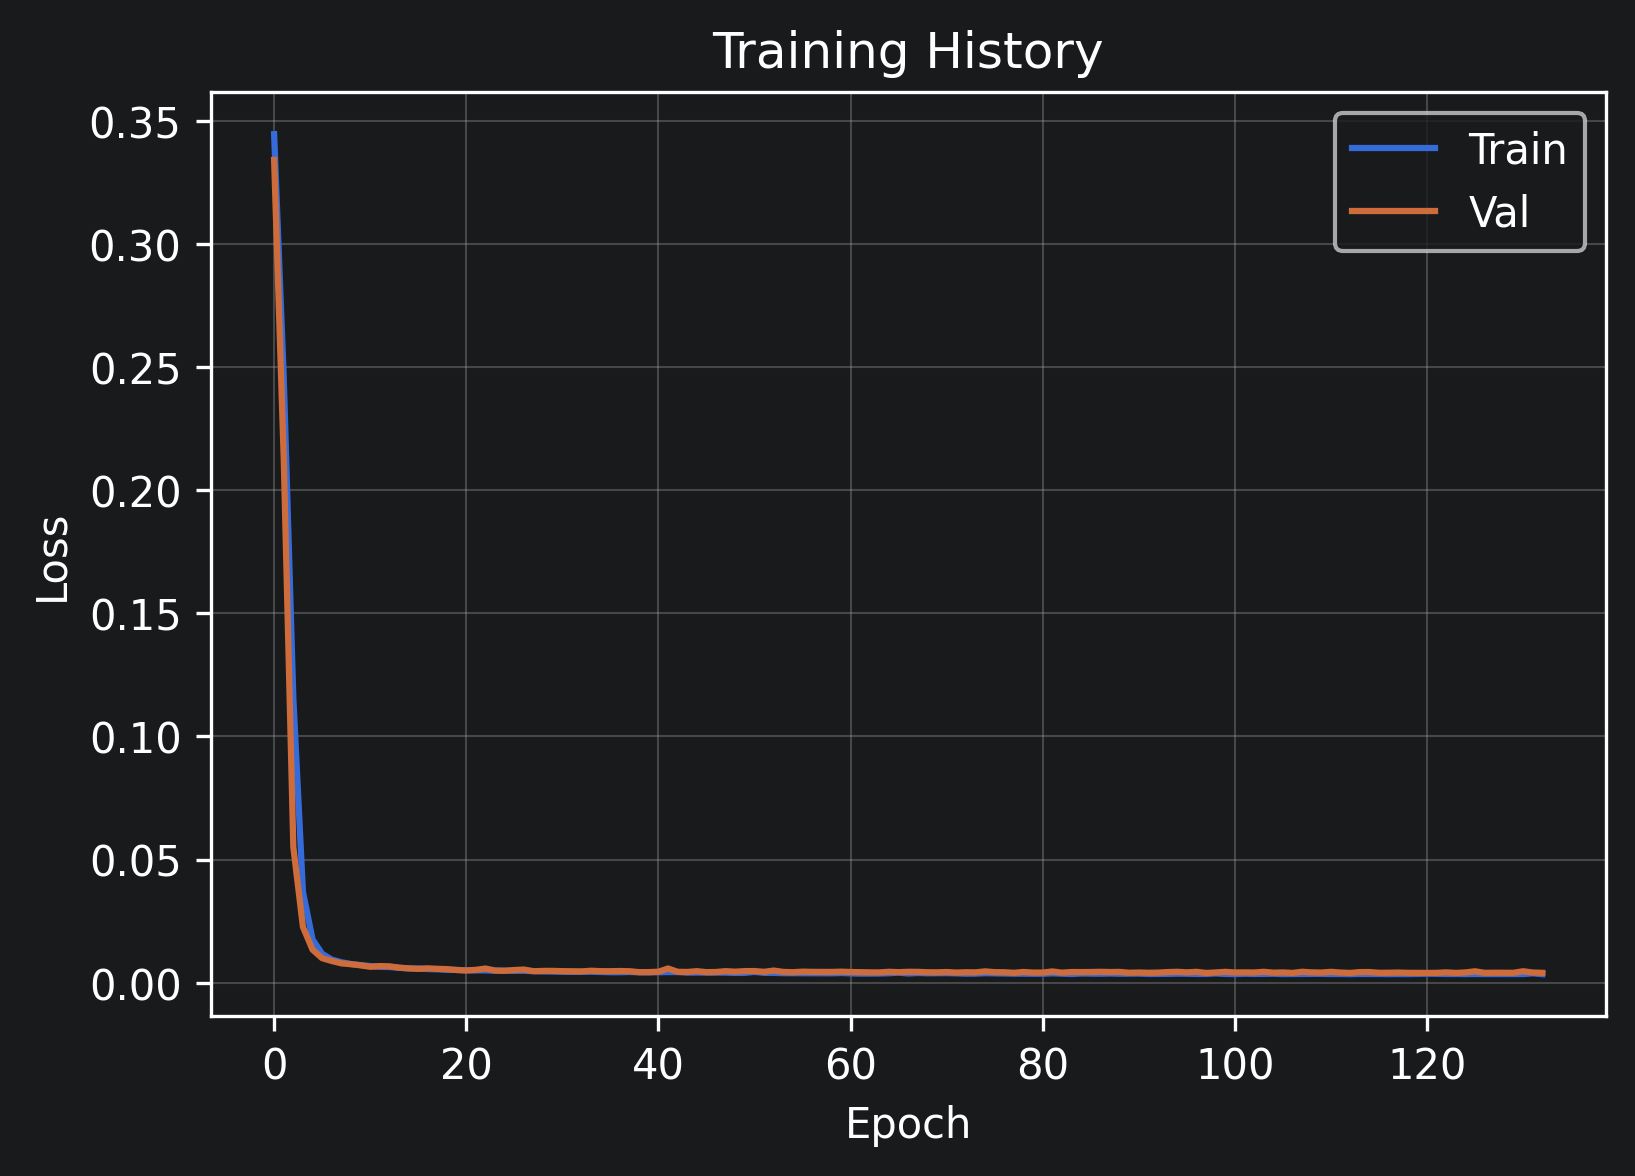

CPU times: user 1.38 s, sys: 105 ms, total: 1.49 s
Wall time: 1.52 s


In [10]:
%%time

fit_config = remu.FitConfig(
    epochs=best_config["epochs"],
    device="cpu",
    early_stopping_patience=best_config["early_stopping_patience"],
    gradient_clipping=best_config["gradient_clipping"],
)

model = remu.build_four_param_model(best_config)
optimizer = remu.build_optimizer(model, best_config)
loss_fn = torch.nn.MSELoss()

history = remu.fit(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    optimizer=optimizer,
    loss_fn=loss_fn,
    config=fit_config,
)

print(type(history))
print(history.keys())
print("Epochs Recorded:", len(history["train_loss"]))
print("Best Val Loss:", min(history["val_loss"]))

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Predict Function

In [11]:
def predict(params, model, X_mean, X_std, Y_mean=None, Y_std=None, normalize_Y=True):
    params = (params - X_mean) / X_std

    xb = torch.from_numpy(params).to(device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(xb).cpu().numpy()

    if normalize_Y:
        pred_log = pred_norm * Y_std + Y_mean
    else:
        pred_log = pred_norm

    pred_dl = np.exp(pred_log)
    return pred_dl

# 10. K-Fold cross-validation

With a tuned architecture in hand, the package also exposes a higher-level K-Fold CV utility that repeatedly rebuilds, trains, and evaluates fresh models across folds.

### Main function
- `remu.kfold_cross_validate(...)`

### Main config
- `remu.KFoldConfig(...)`

### Return object
A `dict` containing:

- `"ell"` - ell bin centers
- `"fold_best_val"` - list of best validation losses per fold
- `"mean_best_val"` - mean best validation loss
- `"std_best_val"` - standard deviation of best validation loss
- `"models"` - list of trained model instances, one per fold
- `"norms"` -  list of dicts per fold, each with keys "X" and "Y" containing the fitted standardizer for that fold (None if normalization disabled)
- `"val_indices"` - list of np.ndarray of validation indices per fold
- `"histories"` — optional, included when `return_histories=True`



=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.350592, val=0.288691
Epoch 002: train=0.227771, val=0.142050
Epoch 003: train=0.076995, val=0.042012
Epoch 004: train=0.030328, val=0.023760
Epoch 005: train=0.018579, val=0.016209
Epoch 006: train=0.013251, val=0.012819
Epoch 007: train=0.010753, val=0.010991
Epoch 008: train=0.009220, val=0.009666
Epoch 009: train=0.008432, val=0.008918
Epoch 010: train=0.007654, val=0.008421
Epoch 011: train=0.007112, val=0.007944
Epoch 012: train=0.006849, val=0.007402
Epoch 013: train=0.006400, val=0.007027
Epoch 014: train=0.006052, val=0.006708
Epoch 015: train=0.005902, val=0.006590
Epoch 016: train=0.005807, val=0.006293
Epoch 017: train=0.005639, val=0.006128
Epoch 018: train=0.005587, val=0.006232
Epoch 019: train=0.005259, val=0.005981
Epoch 020: train=0.005128, val=0.006040
Epoch 021: train=0.005082, val=0.005835
Epoch 022: train=0.005042, val=0.005613
Epoch 023: train=0.004903, val=0.005666
Epoch 024: train=0.004833, val=0.005437
Ep

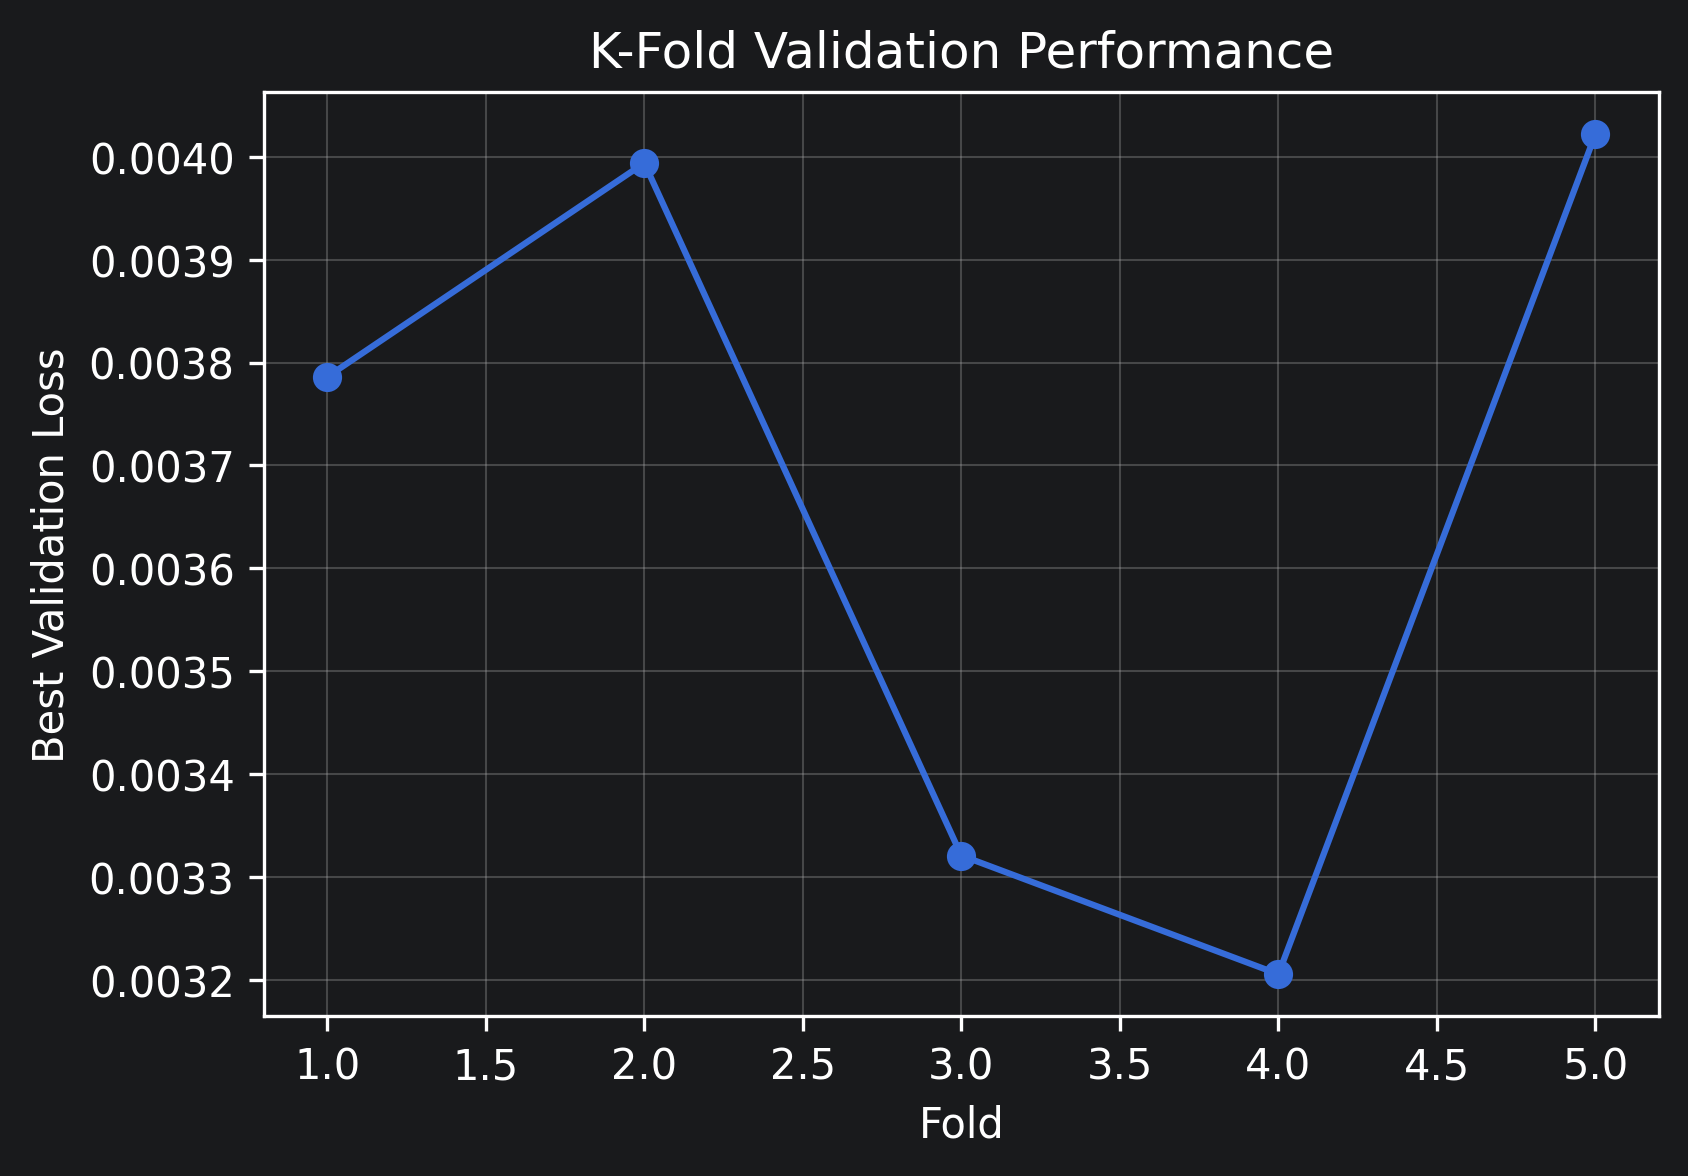

CPU times: user 4.46 s, sys: 15.8 ms, total: 4.48 s
Wall time: 4.47 s


In [12]:
%%time

kfold_config = remu.KFoldConfig(
    k=5,
    seed=42,
    return_histories=True,
)

cv_result = remu.kfold_cross_validate(
    h5_path=condensed_h5,
    model_builder=lambda: remu.build_four_param_model(best_config),
    optimizer_builder=lambda model: remu.build_optimizer(model, best_config),
    loss_fn=torch.nn.MSELoss(),
    kfold_config=kfold_config,
    dl_config=dl_config,
    fit_config=fit_config,
)

print(type(cv_result))
print(cv_result.keys())
print("ell Shape:", cv_result["ell"].shape)
print("Fold Best Val Losses:", cv_result["fold_best_val"])
print("Mean Best Val:", cv_result["mean_best_val"])
print("STD Best Val:", cv_result["std_best_val"])
print("Number of Histories:", len(cv_result["histories"]))

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(cv_result["fold_best_val"]) + 1),
    cv_result["fold_best_val"],
    marker="o",
)
plt.xlabel("Fold")
plt.ylabel("Best Validation Loss")
plt.title("K-Fold Validation Performance")
plt.grid(True, alpha=0.3)
plt.show()


## Calculating Percent Errors of Folds

In [13]:
%%time

X, Y, ell = remu.load_training_arrays(condensed_h5)
device = torch.device("cpu")

fold_pct_errors = []

for fold_idx in range(kfold_config.k):
    fold_model = cv_result["models"][fold_idx]
    fold_norm = cv_result["norms"][fold_idx]
    val_indices = cv_result["val_indices"][fold_idx]

    X_val = X[val_indices]
    Y_val = Y[val_indices]

    X_mean = fold_norm["X"].mean
    X_std = fold_norm["X"].std
    Y_mean = fold_norm["Y"].mean if dl_config.normalize_Y else None
    Y_std = fold_norm["Y"].std if dl_config.normalize_Y else None

    pred = predict(
        X_val,
        fold_model,
        X_mean,
        X_std,
        Y_mean,
        Y_std,
        normalize_Y=dl_config.normalize_Y,
    )
    true = np.exp(Y_val)

    pct_err = np.mean(np.abs((pred - true) / true)) * 100
    fold_pct_errors.append(pct_err)
    print(f"Fold {fold_idx + 1} % Error: {pct_err:.2f}%")

print()
print(f"CV Mean % Error: {np.mean(fold_pct_errors):.2f}%")
print(f"CV Std  % Error: {np.std(fold_pct_errors):.2f}%")

Fold 1 % Error: 4.68%
Fold 2 % Error: 4.74%
Fold 3 % Error: 4.36%
Fold 4 % Error: 4.27%
Fold 5 % Error: 4.84%

CV Mean % Error: 4.58%
CV Std  % Error: 0.22%
CPU times: user 1.49 ms, sys: 795 μs, total: 2.29 ms
Wall time: 1.68 ms
